## Import Libraries

Importing all the necessary libraries we need.
We’ll be using:
- **pandas** for data manipulation
- **matplotlib** and **seaborn** for data visualization

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [3]:
sns.set(style="darkgrid")
plt.rcParams["figure.figsize"] = (14, 6)

## Load Sample Data

We’re using a pre-saved sample of AAPL (Apple Inc.) historical stock data.  
The dataset is loaded from `../data/sample/`, and we convert the `Date` column to datetime format and set it as the index for time series analysis.

In [4]:
df = pd.read_csv("../data/sample/AAPL_historical_sample.csv")
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)
df.head()

/var/folders/w_/j51psmx961g5qp6tmmyx79sr0000gn/T/ipykernel_34552/4049250468.py:2: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df["Date"] = pd.to_datetime(df["Date"])


,Open,High,Low,Close,Volume,Dividends,Stock Splits,Ticker
Date,,,,,,,,
2023-01-03 00:00:00-05:00,128.782649,129.395518,122.742873,123.632530,112117500,0.0,0.0,AAPL
2023-01-04 00:00:00-05:00,125.431615,127.181276,123.642420,124.907707,89113600,0.0,0.0,AAPL
2023-01-05 00:00:00-05:00,125.668849,126.301493,123.326093,123.583099,80962700,0.0,0.0,AAPL
2023-01-06 00:00:00-05:00,124.561717,128.792516,123.454587,128.130219,87754700,0.0,0.0,AAPL
2023-01-09 00:00:00-05:00,128.970474,131.876686,128.397138,128.654144,70790800,0.0,0.0,AAPL


## Data Overview

Looking at the structure of data and making sure there are no msising values:
- `df.info()` gives us column types and null counts
- `df.describe()` provides summary statistics like mean, std, min, max
- `df.isnull().sum()` can reveal if there’s any missing data to handle

In [8]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 576 entries, 2023-01-03 00:00:00-05:00 to 2025-04-21 00:00:00-04:00
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          576 non-null    float64
 1   High          576 non-null    float64
 2   Low           576 non-null    float64
 3   Close         576 non-null    float64
 4   Volume        576 non-null    int64  
 5   Dividends     576 non-null    float64
 6   Stock Splits  576 non-null    float64
 7   Ticker        576 non-null    object 
dtypes: float64(6), int64(1), object(1)
memory usage: 40.5+ KB
None
             Open        High         Low       Close        Volume  \
count  576.000000  576.000000  576.000000  576.000000  5.760000e+02   
mean   193.280134  195.279739  191.564913  193.550628  5.844674e+07   
std     29.680696   29.923397   29.302307   29.646622  2.572155e+07   
min    124.561717  126.301493  122.742873  123.583099  2.323470e+07   
25

## AAPL Closing Price Over Time
Plotting the closing price of AAPL to observe the general trends over time. 

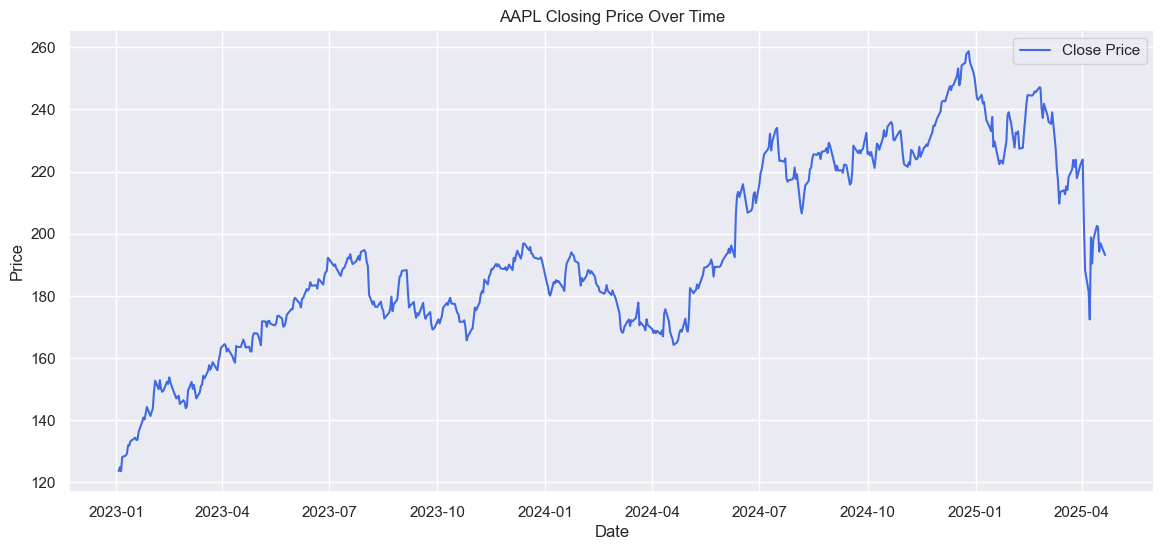

In [7]:
plt.plot(df.index, df["Close"], label="Close Price", color="royalblue")
plt.title("AAPL Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

## Daily Returns
The % change in closing price is calculated to get the daily returns. This helps analyse volatility, performance,, and also helps with future opredictions.

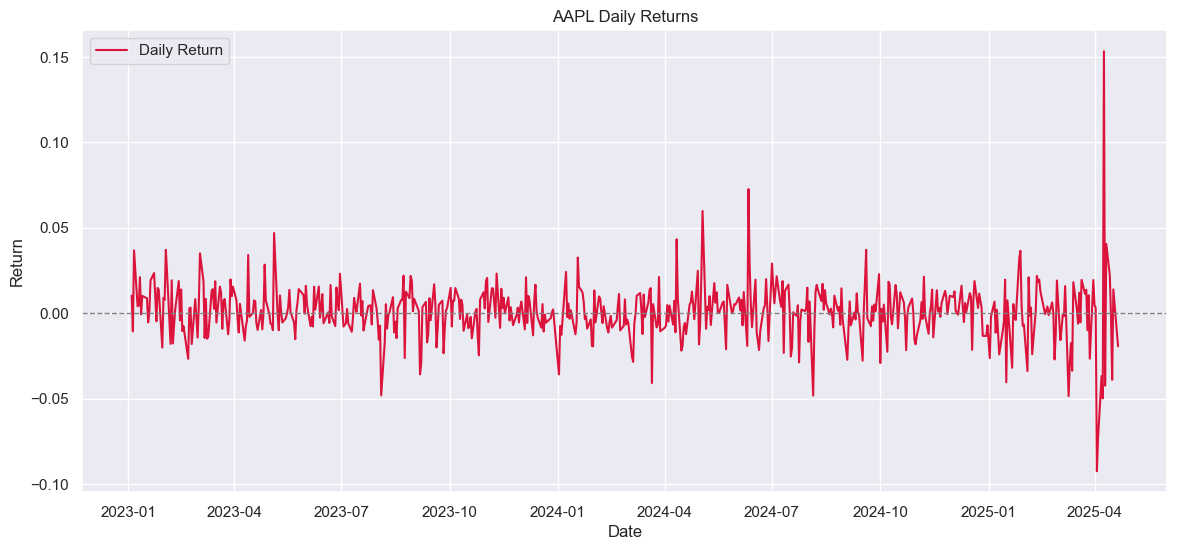

In [9]:
df["Daily Return"] = df["Close"].pct_change()

plt.plot(df.index, df["Daily Return"], color="crimson", label="Daily Return")
plt.axhline(0, linestyle="--", color="gray", linewidth=1)
plt.title("AAPL Daily Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.show()

## Daily Return Distributiom
The distribution of the daily returns helps us understand the volatility of the stock. 

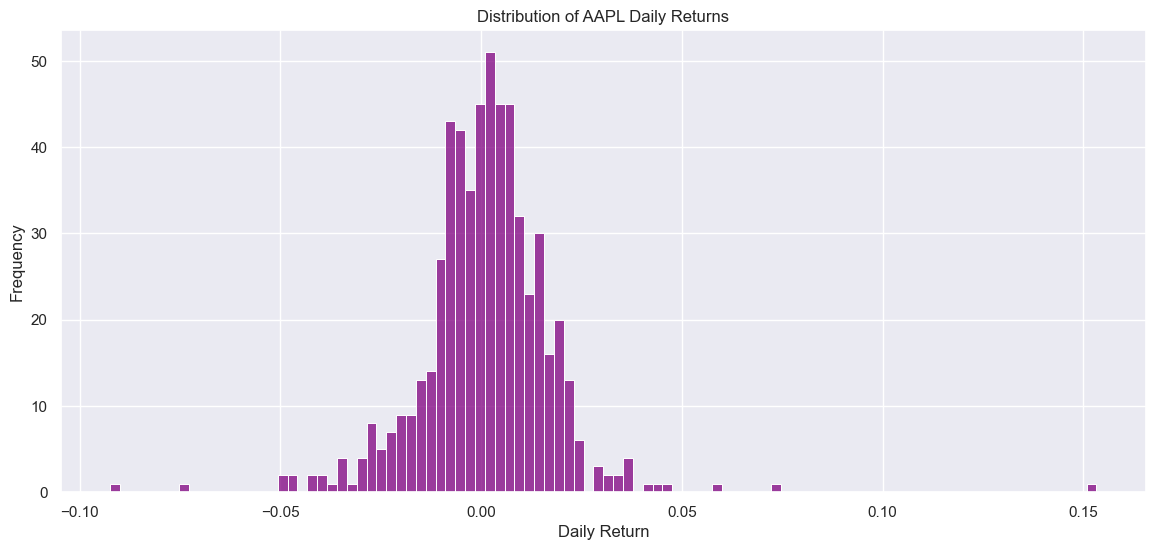

In [10]:
sns.histplot(df["Daily Return"].dropna(), bins=100, color="purple")
plt.title("Distribution of AAPL Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()

## Moving Averages
Looking at moving averages can smooth-out any short-term fluctuations and put more of a highlight on long-term trends.
Plotting the 20-day and 50-day moving average and plotting them alongside the actual closing price.

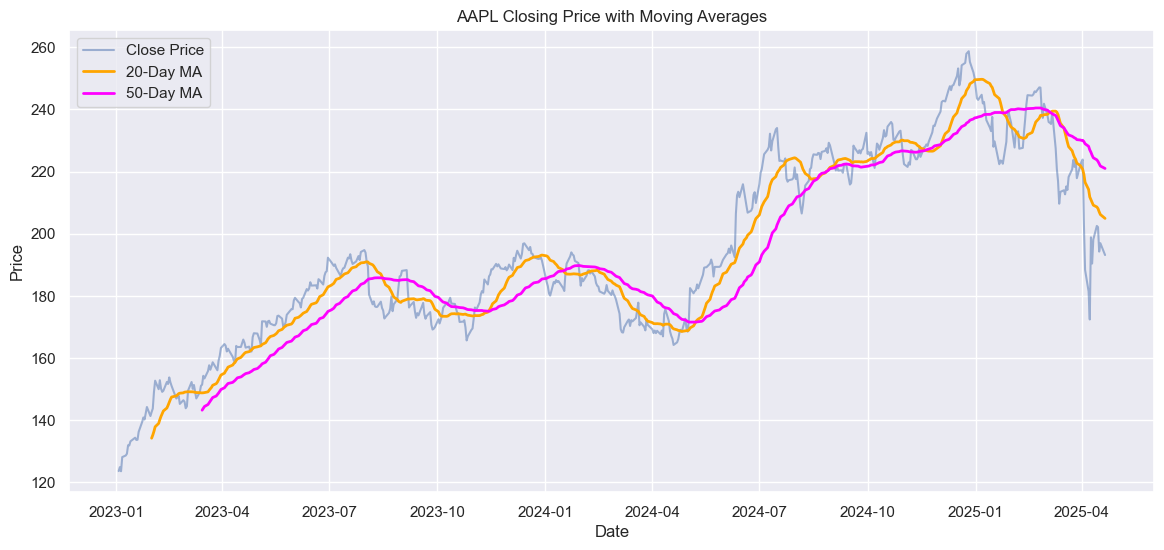

In [11]:
df["MA20"] = df["Close"].rolling(window=20).mean()
df["MA50"] = df["Close"].rolling(window=50).mean()

plt.plot(df.index, df["Close"], label="Close Price", alpha=0.5, linewidth=1.5)
plt.plot(df.index, df["MA20"], label="20-Day MA", color="orange", linewidth=2)
plt.plot(df.index, df["MA50"], label="50-Day MA", color="magenta", linewidth=2)
plt.title("AAPL Closing Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()